# import libraries

In [18]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

import seaborn as sns
import random
import glob
import cv2
import albumentations as A
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from keras.preprocessing.image import  ImageDataGenerator
from keras.layers import Dense,Flatten
from keras.callbacks import EarlyStopping,ModelCheckpoint
from keras import Model
from sklearn.metrics import classification_report , confusion_matrix

# get images from dataset files

In [19]:
positive = glob.glob('/kaggle/input/preprocessed-ct-scans-for-covid19/Original CT Scans/pCT/*.jpg')
nigative = glob.glob('/kaggle/input/preprocessed-ct-scans-for-covid19/Original CT Scans/nCT/*.jpg')


random.shuffle(positive)
random.shuffle(nigative)

train_positive = positive [:int (len (positive) *0.8)]
test_positive = positive[int (len (positive) *0.8):]

train_nigative =nigative [:int (len (nigative) *0.8)]
test_nigative = nigative[int (len (nigative) *0.8):]

print ('number of train positive CT = {}'.format(len (train_positive)))
print ('number of train nigative CT = {}'.format(len (train_nigative)))

print ('------------------------------------')

print ('number of test positive CT = {}'.format(len (test_positive)))
print ('number of test nigative CT = {}'.format(len (test_nigative)))

number of train positive CT = 3200
number of train nigative CT = 7983
------------------------------------
number of test positive CT = 801
number of test nigative CT = 1996


# plot sample of each catogery

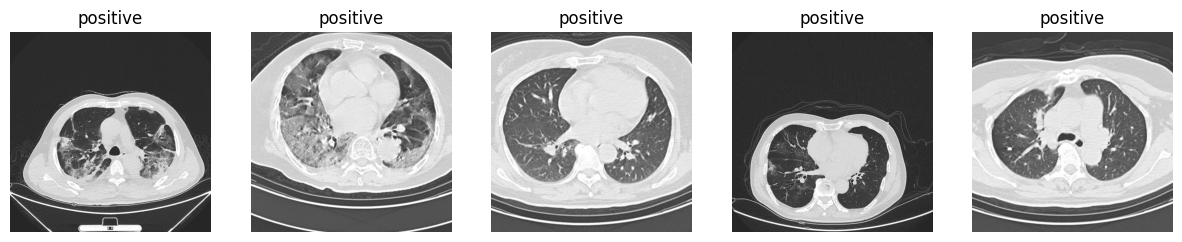

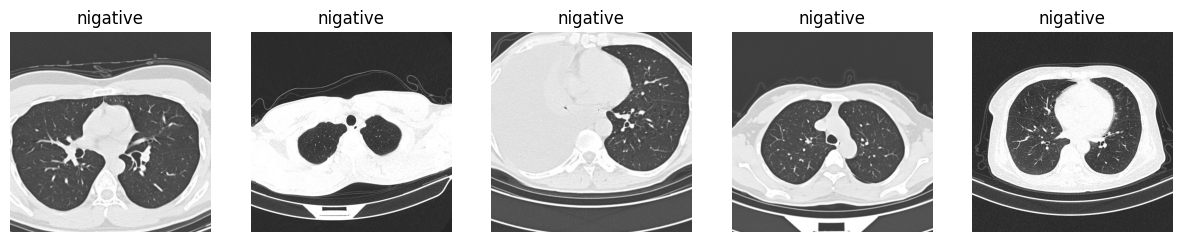

In [20]:
def plot_images (data ,image_title,num_of_images ,type_image = 'bgr'):
    plt.figure(figsize=(15,10))
    for i in range (num_of_images):
        random_image = random.choice(data)
        if type (data) == list:
            random_image = cv2.imread(random_image)
            
        if type_image.lower() == 'bgr':
            random_image =  cv2.cvtColor(random_image, cv2.COLOR_BGR2RGB)
            
        plt.subplot(1,num_of_images,i+1)
        plt.imshow(random_image)
        plt.axis('off')
        plt.title (image_title)
    
    plt.show()
plot_images (train_positive ,'positive',5)
plot_images (train_nigative ,'nigative',5)

# plot categories distribution

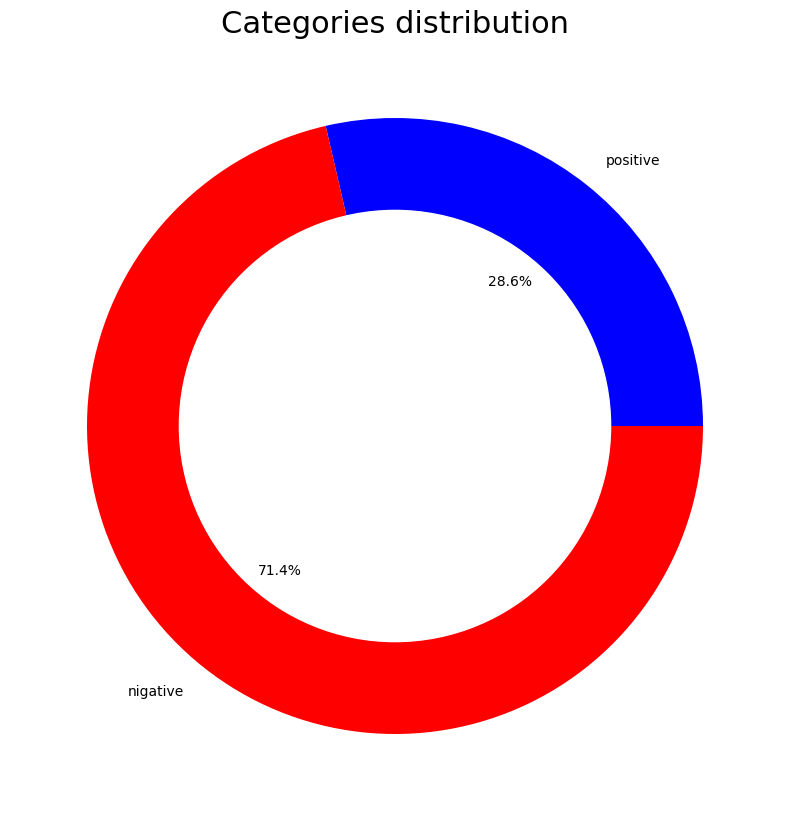

In [21]:
def plt_pie (data,labels,colors,title):
    plt.figure(figsize=(20,10))
    my_circle=plt.Circle( (0,0), 0.7, color='white')
    plt.pie(data,labels = labels, colors = colors , autopct='%1.1f%%')
    p=plt.gcf()
    p.gca().add_artist(my_circle)
    plt.title (title,fontsize = 22)
    plt.show()
    
data = [len (train_positive) , len (train_nigative) ]
labels = ['positive' , 'nigative']
colors = ['blue','red']
plt_pie (data,labels,colors , 'Categories distribution')

# define functions to agumante image

In [22]:
def image_augmentation(low_data,target , p=0.5):
    
    images =[]
    
    albumentation_list = [A.RandomBrightness(limit = 0.5, p=p),A.RGBShift(p=p), A.RandomContrast(limit = 0.5,p =p) ,
                          A.Rotate(p=p, limit=40) , A.RandomCrop(p=p,height = 200, width = 200)]
    
    while (len (images) < target):
        for image in low_data:
            img = cv2.resize(cv2.imread(image), (256, 256) )
            operation = random.choice(albumentation_list)
            img = operation (image = img)['image']
            
            if img.shape[0] !=256:
                img = cv2.resize (img , (256, 256))
    
            images.append (img)
        
            if (len (images) >= target):
                break
    return np.array (images)

# convert link of images to images and resize it

In [23]:
def convert_links_to_images(data):
    images =[]
    for image in data:
        img = cv2.resize(cv2.imread(image), (256, 256) )
        images.append(img)
    return np.array (images)

In [34]:
import cv2
import numpy as np
import random

def mixup_augmentation(low_data, target, alpha=0.4):
    """
    Mixup augmentation: Trộn hai hình ảnh và nhãn của chúng theo tỷ lệ ngẫu nhiên.
    
    Args:
        low_data (list): Danh sách các đường dẫn đến hình ảnh.
        target (int): Số lượng hình ảnh cần tạo.
        alpha (float): Tham số alpha để điều chỉnh phân phối Beta (mặc định là 0.4).
    
    Returns:
        np.array: Mảng các hình ảnh đã được mixup.
    """
    images = []
    
    while len(images) < target:
        # Chọn hai hình ảnh ngẫu nhiên
        img1_path, img2_path = random.sample(low_data, 2)
        
        # Đọc và resize hình ảnh
        img1 = cv2.resize(cv2.imread(img1_path), (256, 256))
        img2 = cv2.resize(cv2.imread(img2_path), (256, 256))
        
        # Tạo lambda từ phân phối Beta
        lam = np.random.beta(alpha, alpha)
        
        # Trộn hai hình ảnh
        mixed_img = lam * img1 + (1 - lam) * img2
        
        # Đảm bảo giá trị pixel nằm trong khoảng [0, 255]
        mixed_img = np.clip(mixed_img, 0, 255).astype(np.uint8)
        
        images.append(mixed_img)
        
        if len(images) >= target:
            break
    
    return np.array(images)

# apply functions to agumante images and and balncing distribution of images

In [24]:
train_positive_images = image_augmentation(train_positive,8000,p=1)
train_negative_images = image_augmentation(train_nigative,8000,p=1)

test_positive_images = convert_links_to_images(test_positive)
test_negative_images = convert_links_to_images(test_nigative)  


In [35]:
train_positive_images = mixup_augmentation(train_positive,8000,alpha=0.4)
train_negative_images = mixup_augmentation(train_nigative,8000,alpha=0.4)

test_positive_images = convert_links_to_images(test_positive)
test_negative_images = convert_links_to_images(test_nigative)  


# plot distribution of train data after balncing

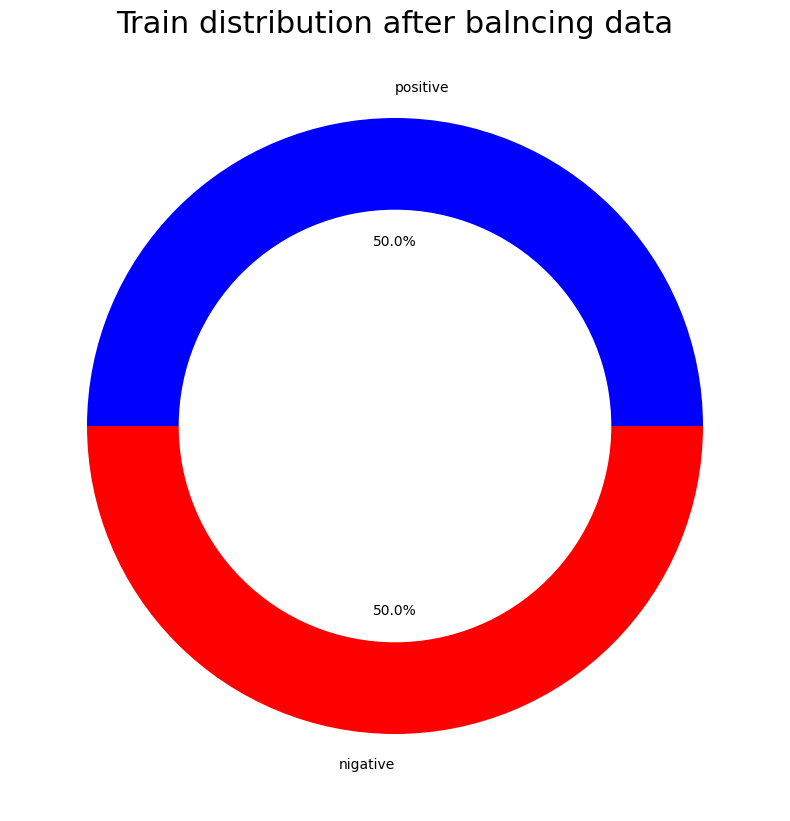

In [25]:
plt_pie ([len (train_positive_images) ,len (train_negative_images)] ,labels,colors,'Train distribution after balncing data')

# plot sample from each category after preprocessing

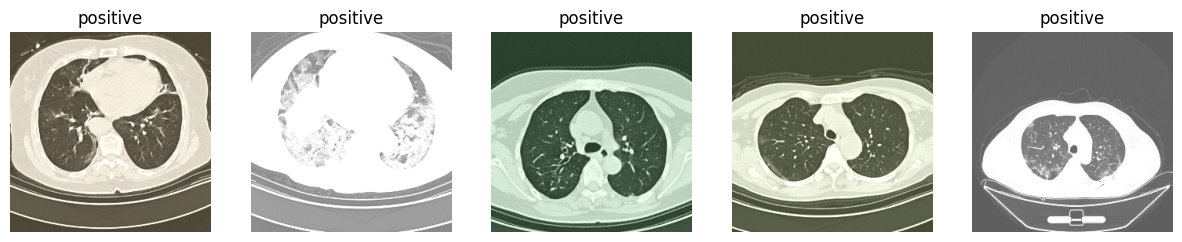

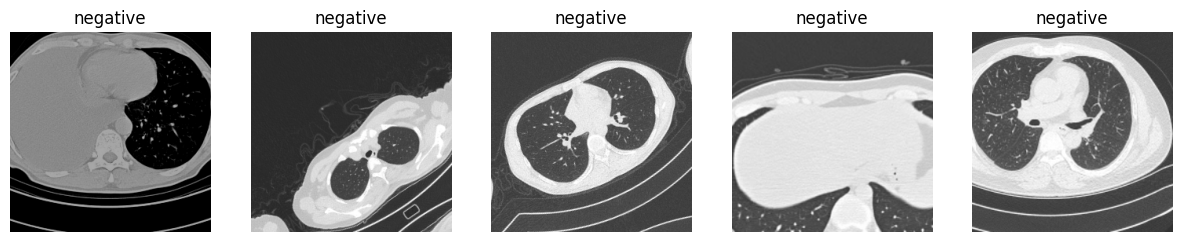

In [26]:
#Train data
plot_images (train_positive_images ,'positive',5)
plot_images (train_negative_images ,'negative',5)


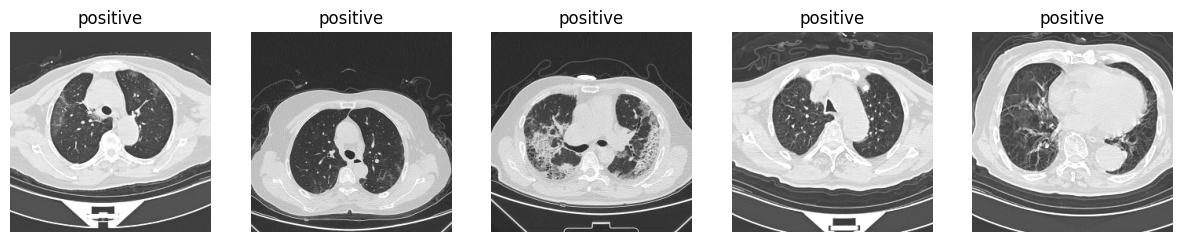

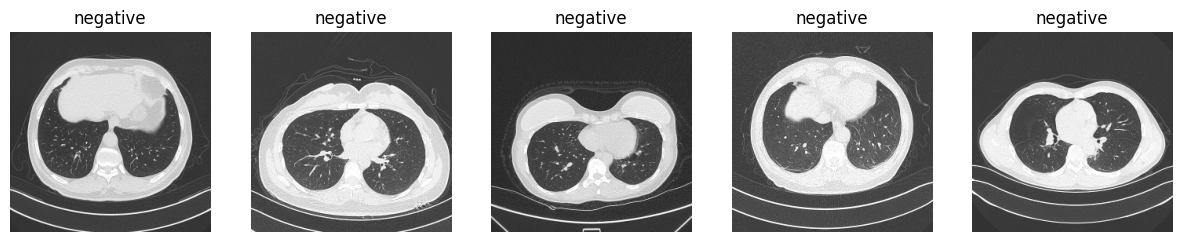

In [27]:
#Test data
plot_images (test_positive_images ,'positive',5)
plot_images (test_negative_images ,'negative',5)


# get train and test data

In [28]:
# Chỉ sử dụng dữ liệu từ hai lớp: positive và negative
y_train = np.concatenate([np.zeros(len(train_positive_images)), np.ones(len(train_negative_images))])
y_train = keras.utils.to_categorical(y_train, num_classes=2)  # Chỉ 2 lớp
X_train = np.concatenate([train_positive_images, train_negative_images], axis=0)

y_test = np.concatenate([np.zeros(len(test_positive_images)), np.ones(len(test_negative_images))])
y_test = keras.utils.to_categorical(y_test, num_classes=2)  # Chỉ 2 lớp
X_test = np.concatenate([test_positive_images, test_negative_images], axis=0)

# In kích thước dữ liệu
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

# Giải phóng bộ nhớ
train_positive_images, train_negative_images, test_positive_images, test_negative_images = None, None, None, None
del train_positive_images, train_negative_images, test_positive_images, test_negative_images

(16000, 256, 256, 3)
(16000, 2)
(2797, 256, 256, 3)
(2797, 2)


# create image datagenerator for train and test data

In [ ]:
train_datagen = ImageDataGenerator( rescale=1./255,
                                    rotation_range=40,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    shear_range=0.2,
                                    zoom_range=0.2,
                                    horizontal_flip=True,
                                    fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1./255,)

train_generator = train_datagen.flow(X_train, y_train,batch_size=16,shuffle=True)
test_generator = test_datagen.flow(X_test, y_test,batch_size=16,shuffle=False)
#--------------------------------free some memory--------------------------------

In [ ]:
import tensorflow as tf
from tensorflow.keras import backend as K

def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fn(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
        cross_entropy = -y_true * K.log(y_pred)
        loss = alpha * K.pow(1.0 - y_pred, gamma) * cross_entropy
        return K.sum(loss, axis=-1)
    return focal_loss_fn

# get inception_v3 pre trained model

In [13]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, Add, AveragePooling2D, Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

def residual_block(x, filters, kernel_size=3, stride=1, conv_shortcut=False):
    """Residual block for ResNet."""
    if conv_shortcut:
        shortcut = Conv2D(filters, kernel_size=1, strides=stride, padding='same')(x)
        shortcut = BatchNormalization()(shortcut)
    else:
        shortcut = x

    # First convolution layer
    x = Conv2D(filters, kernel_size, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Second convolution layer
    x = Conv2D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)

    # Add shortcut
    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x

def build_resnet32(input_shape=(256, 256, 3), num_classes=10):
    """Build ResNet32 model."""
    inputs = Input(shape=input_shape)

    # Initial convolution layer
    x = Conv2D(16, kernel_size=3, strides=1, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Stack of residual blocks
    num_blocks = 5  # Total layers = 1 + 2 * num_blocks * 3 = 32
    filters = 16

    for _ in range(num_blocks):
        x = residual_block(x, filters)
        x = residual_block(x, filters)

    # Increase filters
    filters *= 2
    x = residual_block(x, filters, stride=2, conv_shortcut=True)
    for _ in range(num_blocks - 1):
        x = residual_block(x, filters)

    # Increase filters again
    filters *= 2
    x = residual_block(x, filters, stride=2, conv_shortcut=True)
    for _ in range(num_blocks - 1):
        x = residual_block(x, filters)

    # Final layers
    x = AveragePooling2D(pool_size=(8, 8))(x)  # Điều chỉnh pool_size phù hợp
    x = Flatten()(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    # Create model
    model = Model(inputs, outputs)
    return model

model = build_resnet32(input_shape=(256, 256, 3), num_classes=2)
# model.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath='model_resnet32.h5', monitor='val_loss', save_best_only=True)
]

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, Add, AveragePooling2D, Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

def residual_block(x, filters, kernel_size=3, stride=1, conv_shortcut=False):
    """Residual block for ResNet."""
    if conv_shortcut:
        shortcut = Conv2D(filters, kernel_size=1, strides=stride, padding='same')(x)
        shortcut = BatchNormalization()(shortcut)
    else:
        shortcut = x

    # First convolution layer
    x = Conv2D(filters, kernel_size, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Second convolution layer
    x = Conv2D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)

    # Add shortcut
    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x

def build_resnet32(input_shape=(256, 256, 3), num_classes=10):
    """Build ResNet32 model."""
    inputs = Input(shape=input_shape)

    # Initial convolution layer
    x = Conv2D(16, kernel_size=3, strides=1, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Stack of residual blocks
    num_blocks = 5  # Total layers = 1 + 2 * num_blocks * 3 = 32
    filters = 16

    for _ in range(num_blocks):
        x = residual_block(x, filters)
        x = residual_block(x, filters)

    # Increase filters
    filters *= 2
    x = residual_block(x, filters, stride=2, conv_shortcut=True)
    for _ in range(num_blocks - 1):
        x = residual_block(x, filters)

    # Increase filters again
    filters *= 2
    x = residual_block(x, filters, stride=2, conv_shortcut=True)
    for _ in range(num_blocks - 1):
        x = residual_block(x, filters)

    # Final layers
    x = AveragePooling2D(pool_size=(8, 8))(x)  # Điều chỉnh pool_size phù hợp
    x = Flatten()(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    # Create model
    model = Model(inputs, outputs)
    return model

model = build_resnet32(input_shape=(256, 256, 3), num_classes=2)
model.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath='model_resnet32.h5', monitor='val_loss', save_best_only=True)
]

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss=focal_loss(gamma=2.0, alpha=0.25),
              metrics=['accuracy'])

# build full-model and fit model

In [14]:
history = model.fit(train_generator,
                    epochs=10,
                    validation_data=test_generator,
                    callbacks=callbacks)

model.load_weights('model_resnet32.h5')

Epoch 1/10
1000/1000 [==============================] - 630s 601ms/step - loss: 0.5979 - accuracy: 0.6976 - val_loss: 0.3697 - val_accuracy: 0.8298
Epoch 2/10
1000/1000 [==============================] - 614s 613ms/step - loss: 0.3608 - accuracy: 0.8407 - val_loss: 0.1252 - val_accuracy: 0.9489
Epoch 3/10
1000/1000 [==============================] - 614s 614ms/step - loss: 0.2894 - accuracy: 0.8778 - val_loss: 1.2137 - val_accuracy: 0.5098
Epoch 4/10
1000/1000 [==============================] - 613s 613ms/step - loss: 0.2534 - accuracy: 0.8961 - val_loss: 0.1137 - val_accuracy: 0.9524
Epoch 5/10
1000/1000 [==============================] - 613s 613ms/step - loss: 0.2054 - accuracy: 0.9184 - val_loss: 0.0741 - val_accuracy: 0.9732
Epoch 6/10
1000/1000 [==============================] - 612s 612ms/step - loss: 0.1881 - accuracy: 0.9241 - val_loss: 0.1565 - val_accuracy: 0.9306
Epoch 7/10
1000/1000 [==============================] - 613s 612ms/step - loss: 0.1700 - accuracy: 0.9339 - val_

In [17]:
import numpy as np
import torch
import pdb

def accuracy(output, target, topk=(1,)):
    """Computes the accuracy over the k top predictions for the specified values of k"""
    with torch.no_grad():
        maxk = max(topk)
        batch_size = target.size(0)

        _, pred = output.topk(maxk, 1, True, True)
        pred = pred.t()
        correct = pred.eq(target.view(1, -1).expand_as(pred))
        
        res = []
#         for k in topk:
#             correct_k = correct[:k].view(-1).float().sum(0, keepdim=True)
#             res.append(correct_k.mul_(100.0 / batch_size).numpy())
        
        correct_k = correct[:1].view(-1).float().sum(0, keepdim=True)
        
        res = correct_k.mul_(100.0 / batch_size).cpu().numpy()

        return res


def calibration(true_labels, pred_labels, confidences, num_bins=15):
    """Collects predictions into bins used to draw a reliability diagram.

    Arguments:
        true_labels: the true labels for the test examples
        pred_labels: the predicted labels for the test examples
        confidences: the predicted confidences for the test examples
        num_bins: number of bins

    The true_labels, pred_labels, confidences arguments must be NumPy arrays;
    pred_labels and true_labels may contain numeric or string labels.

    For a multi-class model, the predicted label and confidence should be those
    of the highest scoring class.

    Returns a dictionary containing the following NumPy arrays:
        accuracies: the average accuracy for each bin
        confidences: the average confidence for each bin
        counts: the number of examples in each bin
        bins: the confidence thresholds for each bin
        avg_accuracy: the accuracy over the entire test set
        avg_confidence: the average confidence over the entire test set
        expected_calibration_error: a weighted average of all calibration gaps
        max_calibration_error: the largest calibration gap across all bins
    """
    assert(len(confidences) == len(pred_labels))
    assert(len(confidences) == len(true_labels))
    assert(num_bins > 0)

    bin_size = 1.0 / num_bins
    bins = np.linspace(0.0, 1.0, num_bins + 1)
    indices = np.digitize(confidences, bins, right=True)

    bin_accuracies = np.zeros(num_bins, dtype=np.float64)
    bin_confidences = np.zeros(num_bins, dtype=np.float64)
    bin_counts = np.zeros(num_bins, dtype=np.int64)

    for b in range(num_bins):
        selected = np.where(indices == b + 1)[0]
        if len(selected) > 0:
            bin_accuracies[b] = np.mean(true_labels[selected] == pred_labels[selected])
            bin_confidences[b] = np.mean(confidences[selected])
            bin_counts[b] = len(selected)

    avg_acc = np.sum(bin_accuracies * bin_counts) / np.sum(bin_counts)
    avg_conf = np.sum(bin_confidences * bin_counts) / np.sum(bin_counts)

    gaps = np.abs(bin_accuracies - bin_confidences)
    ece = np.sum(gaps * bin_counts) / np.sum(bin_counts)
    mce = np.max(gaps)

    return { "accuracies": bin_accuracies, 
             "confidences": bin_confidences, 
             "counts": bin_counts, 
             "bins": bins,
             "avg_accuracy": avg_acc,
             "avg_confidence": avg_conf,
             "expected_calibration_error": ece,
             "max_calibration_error": mce }

In [29]:
y_pred = model.predict(X_test)
pred_labels = np.argmax(y_pred, axis=1)
confidences = np.max(y_pred, axis=1)

true_labels = np.argmax(y_test, axis=1)

calibration_results = calibration(true_labels, pred_labels, confidences, num_bins=15)

print("Expected Calibration Error (ECE):", calibration_results["expected_calibration_error"])
print("Max Calibration Error (MCE):", calibration_results["max_calibration_error"])

88/88 [==============================] - 27s 284ms/step
Expected Calibration Error (ECE): 0.28637826242402575
Max Calibration Error (MCE): 0.28637826242402575


In [ ]:
from tensorflow.keras.models import load_model

model = load_model('model_resnet32.h5')

In [ ]:
from tensorflow.keras.layers import Multiply

# Thêm lớp LWS
def add_lws_layer(model):
    # Lấy đầu ra của mô hình
    logits = model.output
    
    lws_weights = Dense(2, use_bias=False, kernel_initializer='ones', name='lws_weights')(logits)
    scaled_logits = Multiply()([logits, lws_weights])
    
    new_model = Model(inputs=model.input, outputs=scaled_logits)
    return new_model

# Thêm LWS vào mô hình
model_with_lws = add_lws_layer(model)
# model_with_lws.summary()

In [ ]:
import numpy as np

def find_optimal_temperature(model, val_generator):
    # Lấy logits từ mô hình
    val_logits = model.predict(val_generator)
    val_labels = val_generator.classes
    
    # Tìm giá trị T tối ưu
    best_T = 1.0
    best_ece = float('inf')
    
    for T in np.linspace(0.1, 10.0, 100):
        scaled_logits = val_logits / T
        scaled_probs = tf.nn.softmax(scaled_logits, axis=1)
        confidences = np.max(scaled_probs, axis=1)
        pred_labels = np.argmax(scaled_probs, axis=1)
        
        ece = calibration(val_labels, pred_labels, confidences)["expected_calibration_error"]
        
        if ece < best_ece:
            best_ece = ece
            best_T = T
    
    return best_T

# Tìm giá trị T tối ưu trên tập validation
optimal_T = find_optimal_temperature(model_with_lws, test_datagen)
print(f"Optimal Temperature: {optimal_T}")

In [ ]:
def apply_temperature_scaling(model, test_generator, T):
    # Lấy logits từ mô hình
    test_logits = model.predict(test_generator)
    test_labels = test_generator.classes
    
    # Áp dụng Temperature Scaling
    scaled_logits = test_logits / T
    scaled_probs = tf.nn.softmax(scaled_logits, axis=1)
    confidences = np.max(scaled_probs, axis=1)
    pred_labels = np.argmax(scaled_probs, axis=1)
    
    # Tính toán ECE và MCE
    calibration_results = calibration(test_labels, pred_labels, confidences)
    print("Expected Calibration Error (ECE):", calibration_results["expected_calibration_error"])
    print("Max Calibration Error (MCE):", calibration_results["max_calibration_error"])
    
    return scaled_probs, pred_labels, confidences

# Áp dụng Temperature Scaling trên tập test
scaled_probs, pred_labels, confidences = apply_temperature_scaling(model_with_lws, test_datagen, optimal_T)

In [ ]:
def plot_reliability_diagram(calibration_results):
    accuracies = calibration_results["accuracies"]
    confidences = calibration_results["confidences"]
    bins = calibration_results["bins"]
    
    plt.figure(figsize=(8, 6))
    plt.bar(bins[:-1], accuracies, width=0.05, alpha=0.6, label="Accuracy", color="blue")
    plt.plot(bins[:-1], confidences, marker="o", color="red", label="Confidence")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect Calibration")
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title("Reliability Diagram")
    plt.legend()
    plt.show()

# Vẽ reliability diagram
calibration_results = calibration(test_labels, pred_labels, confidences)
plot_reliability_diagram(calibration_results)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Tính toán confusion matrix
cm = confusion_matrix(test_labels, pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=test_generator.class_indices.keys(), 
            yticklabels=test_generator.class_indices.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# In báo cáo phân loại
print(classification_report(test_labels, pred_labels, target_names=test_generator.class_indices.keys()))

# plot loss and accuracy

In [ ]:
model_with_lws.save('model_resnet32_stage2.h5')

In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss'] 
tarin_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(range (len (tarin_acc)),tarin_acc,c='b',label = 'training accuracy')
plt.plot (range (len (val_acc)),val_acc,c='r',label = 'validation accuracy')
plt.title ('model accuracy',loc ='right')
plt.legend()
plt.show()

plt.plot(range (len (train_loss)),train_loss,c='b',label = 'training loss')
plt.plot (range (len (val_loss)),val_loss,c='r',label = 'validation loss')
plt.title ('model loss',loc ='right')
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Lấy dữ liệu từ lịch sử huấn luyện
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']  # Sửa lỗi chính tả từ 'tarin_acc' thành 'train_acc'
val_acc = history.history['val_accuracy']

# Vẽ biểu đồ độ chính xác (accuracy)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)  # Tạo một subplot với 1 hàng, 2 cột, và chọn subplot thứ nhất
plt.plot(range(len(train_acc)), train_acc, c='b', label='Training Accuracy')
plt.plot(range(len(val_acc)), val_acc, c='r', label='Validation Accuracy')
plt.title('Model Accuracy', loc='center')  # Đặt tiêu đề ở giữa
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')  # Đặt chú thích ở góc dưới bên phải
plt.grid(True)  # Thêm lưới để dễ quan sát

# Vẽ biểu đồ hàm mất mát (loss)
plt.subplot(1, 2, 2)  # Chọn subplot thứ hai
plt.plot(range(len(train_loss)), train_loss, c='b', label='Training Loss')
plt.plot(range(len(val_loss)), val_loss, c='r', label='Validation Loss')
plt.title('Model Loss', loc='center')  # Đặt tiêu đề ở giữa
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')  # Đặt chú thích ở góc trên bên phải
plt.grid(True)  # Thêm lưới để dễ quan sát

plt.tight_layout()  # Tự động điều chỉnh khoảng cách giữa các subplot
plt.show()

# print confusion matrix and classification report

In [ ]:
y_pred = np.round (model.predict (test_generator))
y_pred = np.argmax (y_pred,axis =1)
y_test = np.argmax (y_test,axis =1)
sns.heatmap(confusion_matrix(y_test,y_pred),annot = True,fmt='d')
print (classification_report (y_test,y_pred))

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Dự đoán trên tập kiểm tra
y_pred = model.predict(test_generator)  # Dự đoán xác suất
y_pred = np.argmax(y_pred, axis=1)  # Chuyển đổi xác suất thành nhãn lớp

# Lấy nhãn thực tế từ test_generator
y_test = test_generator.classes  # Lấy nhãn thực tế từ generator

# Tạo confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Vẽ heatmap cho confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=test_generator.class_indices.keys(), 
            yticklabels=test_generator.class_indices.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# In báo cáo phân loại
print(classification_report(y_test, y_pred, target_names=test_generator.class_indices.keys()))